In [1]:
!pip install -q gdown
import gdown
gdown.download('https://drive.google.com/uc?id=1fXSN9TLdVGU232CN5UPo5fXr_8SJFw1A', 'Advertising.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1fXSN9TLdVGU232CN5UPo5fXr_8SJFw1A
To: /content/Advertising.csv
100%|██████████| 5.17k/5.17k [00:00<00:00, 7.65MB/s]


'Advertising.csv'

## Veri Görselleştirilmesi

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
veri = pd.read_csv("Advertising.csv")

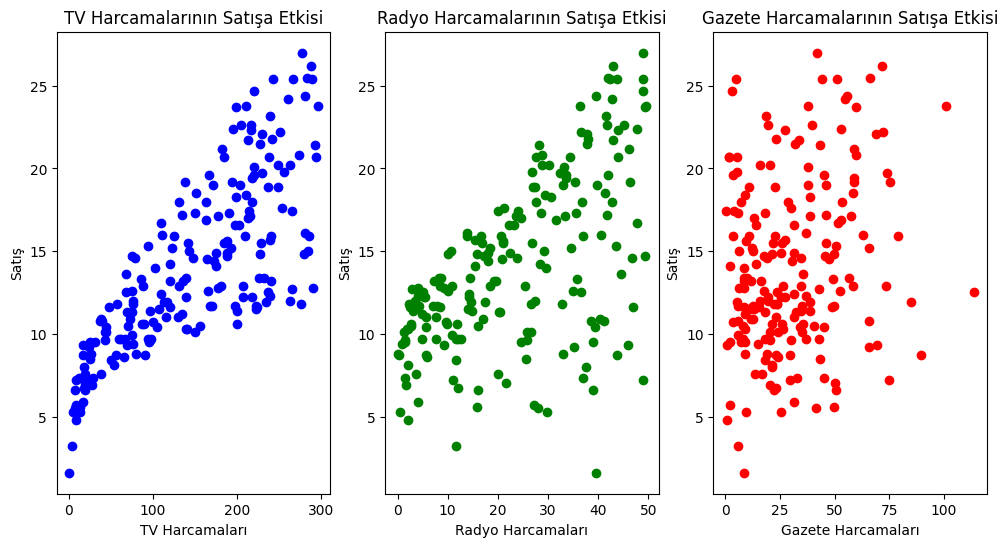

In [9]:
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.scatter(veri['TV'], veri['Sales'], color = 'blue')
plt.title('TV Harcamalarının Satışa Etkisi')
plt.xlabel('TV Harcamaları')
plt.ylabel('Satış')

plt.subplot(1,3,2)
plt.scatter(veri['Radio'], veri['Sales'], color = 'green')
plt.title('Radyo Harcamalarının Satışa Etkisi')
plt.xlabel('Radyo Harcamaları')
plt.ylabel('Satış')

plt.subplot(1,3,3)
plt.scatter(veri['Newspaper'], veri['Sales'], color = 'red')
plt.title('Gazete Harcamalarının Satışa Etkisi')
plt.xlabel('Gazete Harcamaları')
plt.ylabel('Satış')

plt.show()

## Model Oluşturma

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [13]:
X = veri[['TV']]
y = veri['Sales']

In [14]:
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
model = LinearRegression()

In [16]:
model.fit(X_egitim, y_egitim)

LinearRegression()

## Model Tahmini

In [17]:
y_tahmin = model.predict(X_test)

## MSE Hesabı

In [18]:
mse = mean_squared_error(y_test, y_tahmin)
print("MSE hata skoru : ", mse)

MSE hata skoru :  10.204654118800956


## Katsayılar ve Kesişim Noktası

In [19]:
print("Katsayı : ", model.coef_)
print("Kesişim Noktası : ", model.intercept_)

Katsayı :  [0.04652973]
Kesişim Noktası :  7.119638430592953


## Model Grafiği

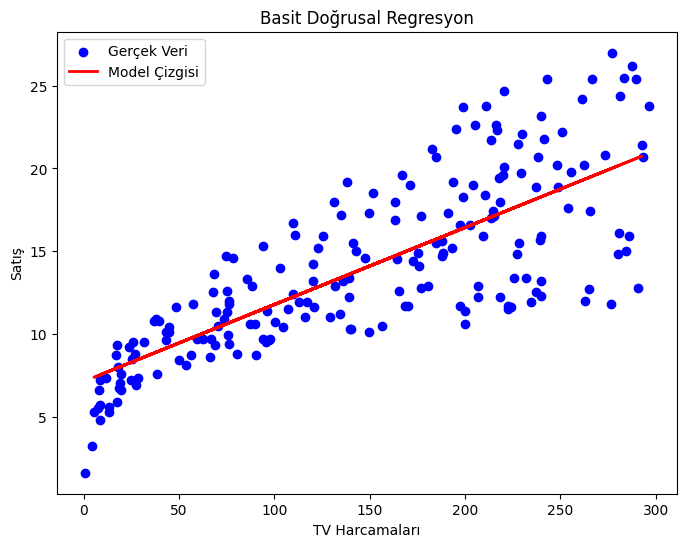

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(X,y, color='blue', label='Gerçek Veri')
plt.plot(X_test,y_tahmin, color='red', linewidth=2, label='Model Çizgisi')

plt.title('Basit Doğrusal Regresyon')
plt.xlabel('TV Harcamaları')
plt.ylabel('Satış')
plt.legend()
plt.show()